=== Model Selection ===


Choose model (MobileViT / DeiT-Tiny):  MobileViT
Choose dataset (Ours / Pooled):  Ours


Loaded classification model: checkpoints/checkpoints_mobileViT_ourData/mobilevit_s_best.pth
Loaded attribute model: checkpoints/checkpoints_mobileViT_ourData_attr/mobilevit_s_attr_best.pth

=== Upload an Image for Prediction ===


Enter full or relative path to image file:  D:\DL_Project\data_pooled\images\team_20_tableware_mug_8.jpg


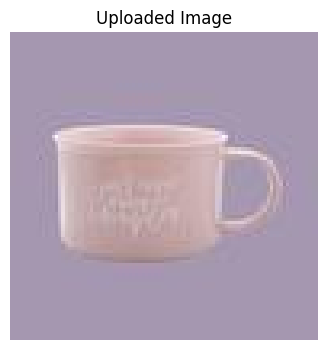


=== RESULTS ===
Model: MobileViT | Dataset: Ours
Predicted Class: cup
Predicted Attributes:
   - color: white
   - material: ceramic
   - pattern: plain


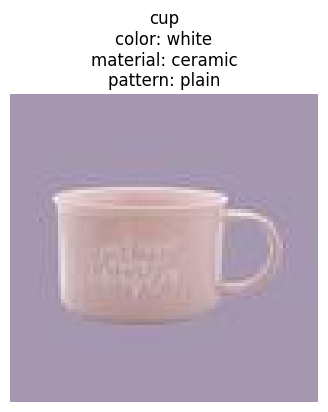

In [11]:
# ============================================
# Minimal Prediction Notebook (Fixed Version)
# ============================================

import os
import torch
import timm
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# ---------------- CONFIG ----------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_CKPT = "checkpoints"

# Map user-friendly names to actual timm model names
MODEL_INTERNALS = {
    "MobileViT": "mobilevit_s",
    "DeiT-Tiny": "deit_tiny_patch16_224"
}

MODEL_PATHS = {
    "MobileViT": {
        "Ours": {
            "class": f"{BASE_CKPT}/checkpoints_mobileViT_ourData/mobilevit_s_best.pth",
            "attr": f"{BASE_CKPT}/checkpoints_mobileViT_ourData_attr/mobilevit_s_attr_best.pth"
        },
        "Pooled": {
            "class": f"{BASE_CKPT}/checkpoints_mobileViT_pooledData/mobilevit_s_best.pth",
            "attr": f"{BASE_CKPT}/checkpoints_mobileViT_pooledData_attr/mobilevit_s_attr_best.pth"
        }
    },
    "DeiT-Tiny": {
        "Ours": {
            "class": f"{BASE_CKPT}/checkpoints_deitTiny_ourData/deit_tiny_patch16_224_best.pth",
            "attr": f"{BASE_CKPT}/checkpoints_deitTiny_ourData_attr/deit_tiny_patch16_224_attr_best.pth"
        },
        "Pooled": {
            "class": f"{BASE_CKPT}/checkpoints_deitTiny_pooledData/deit_tiny_patch16_224_best.pth",
            "attr": f"{BASE_CKPT}/checkpoints_deitTiny_pooledData_attr/deit_tiny_patch16_224_attr_best.pth"
        }
    }
}

CLASS_NAMES = ['backpack', 'comb', 'cup', 'earphones', 'pen',
               'sneakers', 'suitcase', 'wallet', 'water_bottle', 'wrist_watch']

# ---------------- IMAGE TRANSFORMS ----------------
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# ---------------- LOAD MODEL HELPERS ----------------
def load_class_model(model_name, dataset_name):
    ckpt_path = MODEL_PATHS[model_name][dataset_name]["class"]
    internal_name = MODEL_INTERNALS[model_name]
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = timm.create_model(internal_name, pretrained=False, num_classes=len(CLASS_NAMES))
    model.load_state_dict(ckpt["model_state"])
    model = model.to(DEVICE).eval()
    print(f"Loaded classification model: {ckpt_path}")
    return model

def load_attr_model(model_name, dataset_name):
    ckpt_path = MODEL_PATHS[model_name][dataset_name]["attr"]
    internal_name = MODEL_INTERNALS[model_name]
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    top_attrs = ckpt["top_attrs"]
    attr_mappings = ckpt["attr_mappings"]
    num_classes_per_attr = [len(attr_mappings[a]) for a in top_attrs]

    class MultiHeadModel(torch.nn.Module):
        def __init__(self, base_model_name, num_classes_per_attr):
            super().__init__()
            self.backbone = timm.create_model(base_model_name, pretrained=False, num_classes=0)
            in_feats = self.backbone.num_features
            self.heads = torch.nn.ModuleList([torch.nn.Linear(in_feats, n) for n in num_classes_per_attr])

        def forward(self, x):
            feats = self.backbone.forward_features(x)
            if feats.ndim == 4:
                feats = feats.mean(dim=[2, 3])
            return [head(feats) for head in self.heads]

    model = MultiHeadModel(internal_name, num_classes_per_attr).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    print(f"Loaded attribute model: {ckpt_path}")
    return model, top_attrs, attr_mappings


# ---------------- MAIN INTERFACE ----------------
print("=== Model Selection ===")
model_choice = input("Choose model (MobileViT / DeiT-Tiny): ").strip()
dataset_choice = input("Choose dataset (Ours / Pooled): ").strip()

if model_choice not in MODEL_PATHS or dataset_choice not in MODEL_PATHS[model_choice]:
    raise ValueError("Invalid model or dataset selection!")

# Load both models
class_model = load_class_model(model_choice, dataset_choice)
attr_model, top_attrs, attr_mappings = load_attr_model(model_choice, dataset_choice)

# ---------------- UPLOAD + PREDICT ----------------
print("\n=== Upload an Image for Prediction ===")
img_path = input("Enter full or relative path to image file: ").strip()

if not os.path.exists(img_path):
    raise FileNotFoundError(f"File not found: {img_path}")

img = Image.open(img_path).convert("RGB")

# Show the uploaded image
plt.figure(figsize=(4,4))
plt.imshow(np.asarray(img))
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

img_t = val_tfms(img).unsqueeze(0).to(DEVICE)

# --- CLASS PREDICTION ---
with torch.no_grad():
    class_pred = class_model(img_t)
class_idx = torch.argmax(class_pred, dim=1).item()
class_label = CLASS_NAMES[class_idx]

# --- ATTRIBUTE PREDICTION ---
with torch.no_grad():
    outputs = attr_model(img_t)

inv_maps = {a: {v: k for k, v in attr_mappings[a].items()} for a in top_attrs}
pred_attrs = {a: inv_maps[a][torch.argmax(outputs[i], dim=1).item()] for i, a in enumerate(top_attrs)}

# ---------------- DISPLAY ----------------
print("\n=== RESULTS ===")
print(f"Model: {model_choice} | Dataset: {dataset_choice}")
print(f"Predicted Class: {class_label}")
print("Predicted Attributes:")
for a, val in pred_attrs.items():
    print(f"   - {a}: {val}")

# --- Show Image with Predictions ---
plt.figure(figsize=(4,4))
plt.imshow(np.asarray(img))
plt.axis("off")
plt.title(f"{class_label}\n" + "\n".join([f"{k}: {v}" for k,v in pred_attrs.items()]))
plt.show()

In [1]:
import torch
print("PyTorch CUDA Available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


PyTorch CUDA Available: False
Device: cpu


In [2]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sentence_transformers.util import cos_sim
import numpy as np
from sklearn.metrics import mean_squared_error
import sys
from datasets import Dataset, DatasetDict
import sentence_transformers.fit_mixin as fit_mixin

fit_mixin.Dataset = Dataset
fit_mixin.DatasetDict = DatasetDict

In [3]:
def load_and_prepare_data(df):
    """Combine attributes and captions into a single text field."""
    df["text"] = df["attributes"].fillna('') + " | " + df["caption"].fillna('')
    return df

def build_image_text_examples(df):
    """Create (image, text) pairs for CLIP-like fine-tuning."""
    examples = []
    for _, row in df.iterrows():
        img_path = row["image_path"]
        if os.path.exists(img_path):
            examples.append(InputExample(texts=[row["text"]], images=[img_path]))
    return examples


In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

TEAM_DATA = os.path.join(BASE_DIR, "DL_Project\data_team", "labels_team.csv")
TEAM_IMG_DIR = os.path.join(BASE_DIR, "DL_Project\data_team")

POOLED_DATA = os.path.join(BASE_DIR, "DL_Project\data_pooled", "labels_pooled.csv")
POOLED_IMG_DIR = os.path.join(BASE_DIR, "DL_Project\data_pooled")

team_df = pd.read_csv(TEAM_DATA)
pooled_df = pd.read_csv(POOLED_DATA)

In [6]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
import ipywidgets as widgets
from IPython.display import display, clear_output

#Configuration
DATASETS = {
    "Team": {
        "MODEL_PATH": "../DL_Project/data_team/clip_finetuned_team",
        "IMAGE_DIR": "../DL_Project/data_team/images",
        "CACHE_PATH": "../DL_Project/data_team/image_embeddings_cache.pt"
    },
    "Pooled": {
        "MODEL_PATH": "../DL_Project/data_pooled/clip_finetuned_pooled",
        "IMAGE_DIR": "../DL_Project/data_pooled/images",
        "CACHE_PATH": "../DL_Project/data_pooled/image_embeddings_cache.pt"
    }
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {}
IMAGE_EMBS = {}
IMAGE_PATHS = {}

# Helper: Load dataset
def load_dataset(dataset_name):
    cfg = DATASETS[dataset_name]
    model_path, image_dir, cache_path = cfg["MODEL_PATH"], cfg["IMAGE_DIR"], cfg["CACHE_PATH"]

    print(f"\nLoading {dataset_name} CLIP model...")
    model = SentenceTransformer(model_path, device=DEVICE)
    MODELS[dataset_name] = model

    # Load cached embeddings if available
    image_paths = [
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    if len(image_paths) == 0:
        raise ValueError(f"No images found in {image_dir}")

    if os.path.exists(cache_path):
        print(f"Loading cached image embeddings for {dataset_name}...")
        cache = torch.load(cache_path, map_location=DEVICE)
        image_embs = cache["embeddings"]
        old_paths = cache["paths"]
        image_paths = []
        for p in old_paths:
            p = p.replace("\\", "/")                   # unify separators
            filename = p.split("/")[-1]                # extract only file name
            image_paths.append(os.path.join(image_dir, filename))
    else:
        print(f"Found {len(image_paths)} images for {dataset_name}. Encoding...")
        images = [Image.open(p).convert("RGB") for p in image_paths]
        image_embs = model.encode(images, batch_size=16, convert_to_tensor=True, show_progress_bar=True)
        torch.save({"embeddings": image_embs, "paths": image_paths}, cache_path)
        print(f"Cached embeddings for {dataset_name} at {cache_path}")

    IMAGE_EMBS[dataset_name] = image_embs
    IMAGE_PATHS[dataset_name] = image_paths
    print(f"{dataset_name} dataset ready with {len(image_paths)} images.")

# Search Function
def search_images(dataset_name, query, top_k=5):
    model = MODELS[dataset_name]
    image_embs = IMAGE_EMBS[dataset_name]
    image_paths = IMAGE_PATHS[dataset_name]

    query_emb = model.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_emb, image_embs)[0]
    values, indices = torch.topk(cos_scores, k=top_k)
    results = [(image_paths[int(idx)], float(val)) for val, idx in zip(values, indices)]
    return results

# Interactive Jupyter UI
dataset_dropdown = widgets.Dropdown(
    options=["Team", "Pooled"],
    value="Team",
    description="Dataset:",
    layout=widgets.Layout(width='40%')
)

query_box = widgets.Text(
    placeholder="Enter your text query here...",
    description="Query:",
    layout=widgets.Layout(width='60%')
)

topk_slider = widgets.IntSlider(
    value=5, min=1, max=10, step=1, description='Top-K:', continuous_update=False
)

button = widgets.Button(
    description="Search Images",
    button_style='success',
    tooltip='Click to search relevant images'
)

output = widgets.Output()

# Event Handler
def on_button_click(b):
    with output:
        clear_output(wait=True)
        dataset = dataset_dropdown.value
        query = query_box.value.strip()
        if not query:
            print("Please enter a query.")
            return

        # Load model & embeddings if not already loaded
        if dataset not in MODELS:
            load_dataset(dataset)

        print(f"Searching in {dataset} dataset for: '{query}' ...")
        results = search_images(dataset, query, top_k=topk_slider.value)

        plt.figure(figsize=(15, 4))
        for i, (path, score) in enumerate(results):
            plt.subplot(1, topk_slider.value, i + 1)
            img = Image.open(path)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{score:.3f}", fontsize=10)
        plt.show()

button.on_click(on_button_click)

# Display Interface
ui = widgets.VBox([
    widgets.HBox([dataset_dropdown, query_box]),
    topk_slider,
    button,
    output
])
display(ui)
